In [5]:
#!pip install ultralytics

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Set up paths
import os
from pathlib import Path

# Define base paths
DRIVE_PATH = "/content/drive/MyDrive"
PROJECT_PATH = os.path.join(DRIVE_PATH, "problem_statement_5")  # Adjust this to your actual folder name
TRAINING_PATH = os.path.join(PROJECT_PATH, "training", "train_PS05", "train")

# Create paths if they don't exist
os.makedirs(PROJECT_PATH, exist_ok=True)

# List contents to verify structure
print("=== Google Drive Structure ===")
print(f"Drive path: {DRIVE_PATH}")
print(f"Project path: {PROJECT_PATH}")
print(f"Training path: {TRAINING_PATH}")

# Check if training folder exists
if os.path.exists(TRAINING_PATH):
    print(f"\n✅ Training folder found!")
    # Count files
    json_files = len([f for f in os.listdir(TRAINING_PATH) if f.endswith('.json')])
    png_files = len([f for f in os.listdir(TRAINING_PATH) if f.endswith('.png')])
    print(f"📁 JSON files: {json_files}")
    print(f"🖼️ PNG files: {png_files}")

    # Show first few files
    files = os.listdir(TRAINING_PATH)[:10]
    print(f"\n📋 Sample files:")
    for f in files:
        print(f"  - {f}")
else:
    print(f"\n❌ Training folder not found at: {TRAINING_PATH}")
    print("Please check your folder structure and update PROJECT_PATH if needed")

# Set working directory
os.chdir(PROJECT_PATH)
print(f"\n📂 Working directory set to: {os.getcwd()}")

Mounted at /content/drive
=== Google Drive Structure ===
Drive path: /content/drive/MyDrive
Project path: /content/drive/MyDrive/problem_statement_5
Training path: /content/drive/MyDrive/problem_statement_5/training/train_PS05/train

✅ Training folder found!
📁 JSON files: 4008
🖼️ PNG files: 4010

📋 Sample files:
  - doc_04452.png
  - doc_04514.json
  - doc_04425.png
  - doc_04571.png
  - doc_04450.png
  - doc_04509.png
  - doc_04498.json
  - doc_04434.json
  - doc_04563.json
  - doc_04497.json

📂 Working directory set to: /content/drive/MyDrive/problem_statement_5


In [14]:
!pwd

/content/drive/MyDrive/problem_statement_5


In [15]:
#/content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1/weights/best.pth

✅ Model loaded from: /content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1/weights/best.pt

image 1/1 /content/drive/MyDrive/problem_statement_5/training/train_PS05/train/doc_04452.png: 640x640 9 texts, 4 titles, 1 table, 2478.7ms
Speed: 23.9ms preprocess, 2478.7ms inference, 8.1ms postprocess per image at shape (1, 3, 640, 640)
Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 0., 0., 0., 0., 3., 0., 1., 1., 1., 1., 0.])
conf: tensor([0.9961, 0.9960, 0.9957, 0.9956, 0.9948, 0.9948, 0.9934, 0.9902, 0.9807, 0.9743, 0.9717, 0.9666, 0.9619, 0.9618])
data: tensor([[312.9963,  96.3530, 554.1472, 224.8149,   0.9961,   0.0000],
        [312.9417, 319.5628, 554.5010, 424.7438,   0.9960,   0.0000],
        [ 55.0784, 296.2931, 296.1871, 518.7661,   0.9957,   0.0000],
        [ 55.1232,  96.4341, 296.1240, 189.7329,   0.9956,   0.0000],
        [312.9756, 237.2909, 554.2235, 307.4700,   0.9948,   0.0000],
        [313.0941, 437.2165, 554.1

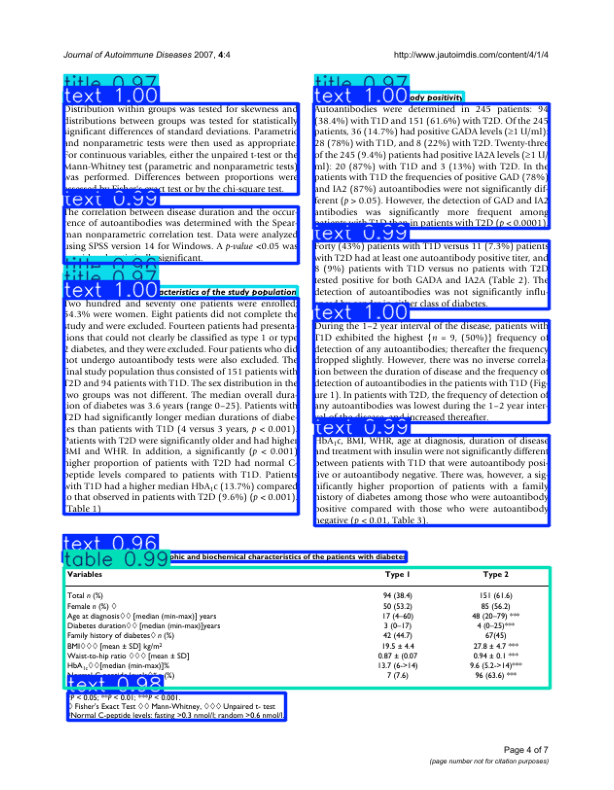

In [16]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# === Paths ===
MODEL_PATH = "/content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1/weights/best.pt"
SAMPLE_IMG = "/content/drive/MyDrive/problem_statement_5/training/train_PS05/train/doc_04452.png"

# 1. Load the trained model
model = YOLO(MODEL_PATH)
print("✅ Model loaded from:", MODEL_PATH)

# 2. Run inference on a sample image
results = model.predict(source=SAMPLE_IMG, conf=0.25, imgsz=640, device="cpu")

# 3. Inspect results
for r in results:
    print("Boxes:", r.boxes)   # xyxy, confidence, class
    print("Classes:", r.boxes.cls.tolist())

# 4. Show visualization
annotated = results[0].plot()   # draw bounding boxes
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [17]:
import wandb

wandb.init(project="rtdetr-layout", job_type="upload-model")

artifact = wandb.Artifact(
    name="rtdetr_foundational_v1",
    type="model",
    description="RT-DETR trained for scientific paper layout detection"
)

artifact.add_file("/content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1/weights/best.pt")
wandb.log_artifact(artifact)

print("✅ Model logged to W&B as an artifact")


✅ Model logged to W&B as an artifact


In [11]:
import wandb

wandb.init(project="rtdetr-layout", job_type="upload-dataset")

artifact = wandb.Artifact(
    name="rtdetr_submissions_v1",   # choose a version name
    type="dataset",
    description="RT-DETR predictions, one JSON per image"
)

artifact.add_dir("/content/drive/MyDrive/problem_statement_5/submissions_final")
wandb.log_artifact(artifact)

print("✅ Submissions folder logged to W&B as dataset artifact")


wandb: Adding directory to artifact (/content/drive/MyDrive/problem_statement_5/submissions_final)... Done. 42.7s


✅ Submissions folder logged to W&B as dataset artifact


In [12]:
import wandb

wandb.init(project="rtdetr-layout", job_type="upload-dataset")

artifact = wandb.Artifact(
    name="scientific_papers_training_v1",
    type="dataset",
    description="Training dataset for RT-DETR on scientific papers (images + JSON annotations)"
)

artifact.add_dir("/content/drive/MyDrive/problem_statement_5/datasets/training_ready")
wandb.log_artifact(artifact)

print("✅ Training dataset logged to W&B as artifact")


wandb: Adding directory to artifact (/content/drive/MyDrive/problem_statement_5/datasets/training_ready)... Done. 3150.1s


✅ Training dataset logged to W&B as artifact


In [18]:
import os
from collections import Counter
from glob import glob
import wandb

# Path to labels (adjust if needed)
LABEL_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/labels"

wandb.init(project="rtdetr-layout", job_type="dataset-analysis")

# Load all .txt files
label_files = glob(os.path.join(LABEL_PATH, "*.txt"))

counts = Counter()

for lf in label_files:
    with open(lf) as f:
        for line in f:
            class_id = int(line.split()[0])  # first token = class
            counts[class_id] += 1

# Map class IDs → names
id2name = {0: "text", 1: "title", 2: "list", 3: "table", 4: "figure"}
class_dist = {id2name[k]: v for k,v in counts.items()}

wandb.log({"class_distribution": class_dist})
print("✅ Logged class distribution:", class_dist)


✅ Logged class distribution: {'text': 146023, 'table': 8119, 'title': 36947, 'figure': 6213, 'list': 3627}


In [19]:
import random
from PIL import Image, ImageDraw

IMG_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/images"

# Pick random sample
sample_imgs = random.sample(glob(os.path.join(IMG_PATH, "*.png")), 10)

table = wandb.Table(columns=["image", "labels"])

for img_path in sample_imgs:
    # Match image with its .txt label
    label_path = img_path.replace("images", "labels").replace(".png", ".txt")
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    labels = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, w, h = line.split()
                cls = int(cls)
                x, y, w, h = map(float, (x, y, w, h))
                labels.append((cls, x, y, w, h))

                # Convert YOLO normalized coords → pixel coords
                W, H = img.size
                x1 = (x - w/2) * W
                y1 = (y - h/2) * H
                x2 = (x + w/2) * W
                y2 = (y + h/2) * H

                draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
                draw.text((x1, y1), id2name[cls], fill="red")

    table.add_data(wandb.Image(img), labels)

wandb.log({"dataset_samples": table})
print("✅ Logged sample images with bounding boxes")

✅ Logged sample images with bounding boxes


## Initializing Full Leaderboard via a new project

In [25]:
# --- SETUP ---
import wandb, os, random, json
import pandas as pd
from glob import glob
from collections import Counter
from PIL import Image, ImageDraw

# Paths
BASE_RUNS = "/content/drive/MyDrive/problem_statement_5/runs"
DATASET_IMG_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/images"
DATASET_LABEL_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/labels"

# Class map
id2name = {0: "text", 1: "title", 2: "list", 3: "table", 4: "figure"}

# Init new project
wandb.init(project="rtdetr-experiments-showcase", job_type="showcase-build")

# --- STEP 1. UPLOAD MODELS & RESULTS ---
for run_name in os.listdir(BASE_RUNS):
    run_dir = os.path.join(BASE_RUNS, run_name)
    ckpt = os.path.join(run_dir, "weights", "best.pt")
    results = os.path.join(run_dir, "results.csv")

    if os.path.exists(ckpt):
        artifact = wandb.Artifact(
            name=f"{run_name}", type="model",
            description=f"RT-DETR checkpoint + metrics from {run_name}"
        )
        artifact.add_file(ckpt)
        if os.path.exists(results):
            artifact.add_file(results)
        wandb.log_artifact(artifact)
        print(f"✅ Logged model + results: {run_name}")

# --- STEP 2. BUILD LEADERBOARD TABLE ---
table = wandb.Table(columns=["run_name", "epochs", "mAP50", "mAP50-95", "precision", "recall"])

for results_csv in glob(BASE_RUNS + "/*/results.csv"):
    run_name = results_csv.split("/")[-2]
    df = pd.read_csv(results_csv)
    final = df.iloc[-1]   # last epoch row
    table.add_data(
        run_name,
        int(final.get("epoch", len(df))),
        float(final.get("metrics/mAP50(B)", 0)),
        float(final.get("metrics/mAP50-95(B)", 0)),
        float(final.get("metrics/precision(B)", 0)),
        float(final.get("metrics/recall(B)", 0))
    )

wandb.log({"model_leaderboard": table})
print("✅ Leaderboard logged")

# --- STEP 3. LOG TRAINING CURVES ---
for results_csv in glob(BASE_RUNS + "/*/results.csv"):
    run_name = results_csv.split("/")[-2]
    df = pd.read_csv(results_csv)

    for _, row in df.iterrows():
        wandb.log({
            "run": run_name,
            "epoch": int(row.get("epoch", 0)),
            "train/box_loss": row.get("train/box_loss", None),
            "train/cls_loss": row.get("train/cls_loss", None),
            "metrics/mAP50": row.get("metrics/mAP50(B)", None),
            "metrics/mAP50-95": row.get("metrics/mAP50-95(B)", None),
            "metrics/precision": row.get("metrics/precision(B)", None),
            "metrics/recall": row.get("metrics/recall(B)", None)
        })
print("✅ Training curves logged")

# --- STEP 4. DATASET INSIGHTS: CLASS DISTRIBUTION ---
label_files = glob(os.path.join(DATASET_LABEL_PATH, "*.txt"))
counts = Counter()

for lf in label_files:
    with open(lf) as f:
        for line in f:
            cls = int(line.split()[0])
            counts[cls] += 1

class_dist = {id2name[k]: v for k, v in counts.items()}
wandb.log({"class_distribution": class_dist})
print("✅ Dataset class distribution logged")

# --- STEP 5. DATASET INSIGHTS: SAMPLE IMAGES ---
# Create W&B Table
table = wandb.Table(columns=["image", "run_name"])

# Pick random images
sample_imgs = random.sample(glob(os.path.join(DATASET_IMG_PATH, "*.png")), 10)

for img_path in sample_imgs:
    label_path = img_path.replace("images", "labels").replace(".png", ".txt")
    img = Image.open(img_path).convert("RGB")

    # Boxes dict for wandb.Image
    boxes = {"ground_truth": {"box_data": [], "class_labels": id2name}}

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, w, h = line.split()
                cls = int(cls)
                x, y, w, h = map(float, (x, y, w, h))

                # Convert YOLO normalized coords → pixel coords
                W, H = img.size
                x1 = (x - w/2) * W
                y1 = (y - h/2) * H
                x2 = (x + w/2) * W
                y2 = (y + h/2) * H

                boxes["ground_truth"]["box_data"].append({
                    "position": {"minX": x1, "minY": y1, "maxX": x2, "maxY": y2},
                    "class_id": cls,
                    "box_caption": id2name[cls]
                })

    # Add to W&B Table with interactive bounding boxes
    table.add_data(wandb.Image(img, boxes=boxes), os.path.basename(img_path))

# Log table to W&B
wandb.log({"dataset_samples": table})
print("✅ Logged dataset sample images with interactive bounding boxes")

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
metrics/mAP50,▁▅▆▇▇▇▇▇██▇█████████████████████████████
metrics/mAP50-95,▁▅▇▇▇███████████████████████████████████
metrics/precision,▁▅▇▇████████████████████████████████████
metrics/recall,▁▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████▇▇███████████████
train/cls_loss,█▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,69
metrics/mAP50,0.98172
metrics/mAP50-95,0.94787
metrics/precision,0.98124
metrics/recall,0.97572


✅ Logged model + results: rtdetr_foundational_v1
✅ Leaderboard logged
✅ Training curves logged
✅ Dataset class distribution logged
✅ Logged dataset sample images with interactive bounding boxes


In [26]:
import os
import json
from glob import glob
from PIL import Image

# Paths
PRED_DIR = "/content/drive/MyDrive/problem_statement_5/submissions_final"

# Create W&B Table
compare_table = wandb.Table(columns=["image", "ground_truth", "predictions", "doc_id"])

# Loop over some prediction files
for pred_file in random.sample(glob(os.path.join(PRED_DIR, "*.json")), 10):
    doc_id = os.path.basename(pred_file).replace(".json", "")
    img_path = os.path.join(DATASET_IMG_PATH, doc_id + ".png")
    label_path = os.path.join(DATASET_LABEL_PATH, doc_id + ".txt")

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path).convert("RGB")

    # -------------------------
    # Ground Truth boxes
    # -------------------------
    gt_boxes = {"ground_truth": {"box_data": [], "class_labels": id2name}}
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, w, h = line.split()
                cls = int(cls)
                x, y, w, h = map(float, (x, y, w, h))
                W, H = img.size
                x1, y1 = (x - w/2) * W, (y - h/2) * H
                x2, y2 = (x + w/2) * W, (y + h/2) * H
                gt_boxes["ground_truth"]["box_data"].append({
                    "position": {"minX": x1, "minY": y1, "maxX": x2, "maxY": y2},
                    "class_id": cls,
                    "box_caption": id2name[cls]
                })

    # -------------------------
    # Prediction boxes
    # -------------------------
    pred_boxes = {"predictions": {"box_data": [], "class_labels": id2name}}
    with open(pred_file) as f:
        preds = json.load(f)

    for p in preds.get("predictions", []):
        cls = int(p["category"])
        x1, y1, x2, y2 = p["bbox"]  # ensure JSON stores [x1,y1,x2,y2]
        pred_boxes["predictions"]["box_data"].append({
            "position": {"minX": x1, "minY": y1, "maxX": x2, "maxY": y2},
            "class_id": cls,
            "box_caption": f"{id2name[cls]} ({p['confidence']:.2f})"
        })

    # -------------------------
    # Add to W&B table
    # -------------------------
    compare_table.add_data(
        wandb.Image(img, boxes=gt_boxes),
        wandb.Image(img, boxes=pred_boxes),
        wandb.Image(img),  # just the raw image if you want side-by-side view
        doc_id
    )

wandb.log({"gt_vs_pred_samples": compare_table})
print("✅ Logged GT vs Pred sample comparisons")


✅ Logged GT vs Pred sample comparisons


In [27]:
!ls /content/drive/MyDrive/problem_statement_5/wandb/artifacts

ls: cannot access '/content/drive/MyDrive/problem_statement_5/wandb/artifacts': No such file or directory


### Made an error...Rebuilding the Project

In [30]:
# --- SETUP ---
import wandb, os, random
import pandas as pd
from glob import glob
from collections import Counter
from PIL import Image
import json

# Paths
RUN_DIR = "/content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1"
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
RESULTS_CSV = os.path.join(RUN_DIR, "results.csv")

DATASET_IMG_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/images"
DATASET_LABEL_PATH = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/train/labels"

# Class map
id2name = {0: "text", 1: "title", 2: "list", 3: "table", 4: "figure"}

# Init new project
wandb.init(project="rtdetr-checkpoints-showcase", job_type="showcase-build")

# --- STEP 1. UPLOAD ALL CHECKPOINTS ---
for ckpt in glob(os.path.join(WEIGHTS_DIR, "*.pt")):
    ckpt_name = os.path.basename(ckpt).replace(".pt", "")
    artifact = wandb.Artifact(
        name=f"rtdetr_foundational_v1_{ckpt_name}",
        type="model",
        description=f"RT-DETR checkpoint {ckpt_name}"
    )
    artifact.add_file(ckpt)
    if os.path.exists(RESULTS_CSV):
        artifact.add_file(RESULTS_CSV)  # attach metrics for traceability
    wandb.log_artifact(artifact)
    print(f"✅ Logged checkpoint: {ckpt_name}")

# --- STEP 2. BUILD CHECKPOINT LEADERBOARD ---
df = pd.read_csv(RESULTS_CSV)
leaderboard = wandb.Table(columns=["checkpoint", "epoch", "mAP50", "mAP50-95", "precision", "recall"])

for _, row in df.iterrows():
    ckpt_name = f"epoch{int(row['epoch'])}"
    leaderboard.add_data(
        ckpt_name,
        int(row["epoch"]),
        float(row.get("metrics/mAP50(B)", 0)),
        float(row.get("metrics/mAP50-95(B)", 0)),
        float(row.get("metrics/precision(B)", 0)),
        float(row.get("metrics/recall(B)", 0))
    )

# Add final best.pt
final = df.iloc[-1]
leaderboard.add_data(
    "best",
    int(final.get("epoch", len(df))),
    float(final.get("metrics/mAP50(B)", 0)),
    float(final.get("metrics/mAP50-95(B)", 0)),
    float(final.get("metrics/precision(B)", 0)),
    float(final.get("metrics/recall(B)", 0))
)

wandb.log({"checkpoint_leaderboard": leaderboard})
print("✅ Leaderboard logged")

# --- STEP 3. LOG TRAINING CURVES ---
for _, row in df.iterrows():
    wandb.log({
        "epoch": int(row.get("epoch", 0)),
        "train/box_loss": row.get("train/box_loss", None),
        "train/cls_loss": row.get("train/cls_loss", None),
        "metrics/mAP50": row.get("metrics/mAP50(B)", None),
        "metrics/mAP50-95": row.get("metrics/mAP50-95(B)", None),
        "metrics/precision": row.get("metrics/precision(B)", None),
        "metrics/recall": row.get("metrics/recall(B)", None)
    })
print("✅ Training curves logged")

# --- STEP 4. DATASET INSIGHTS: CLASS DISTRIBUTION ---
label_files = glob(os.path.join(DATASET_LABEL_PATH, "*.txt"))
counts = Counter()

for lf in label_files:
    with open(lf) as f:
        for line in f:
            cls = int(line.split()[0])
            counts[cls] += 1

class_dist = {id2name[k]: v for k, v in counts.items()}
wandb.log({"class_distribution": class_dist})
print("✅ Dataset class distribution logged")

# --- STEP 5. DATASET INSIGHTS: SAMPLE IMAGES WITH GT BOXES ---
sample_imgs = random.sample(glob(os.path.join(DATASET_IMG_PATH, "*.png")), 10)
table = wandb.Table(columns=["image", "doc_id"])

for img_path in sample_imgs:
    label_path = img_path.replace("images", "labels").replace(".png", ".txt")
    img = Image.open(img_path).convert("RGB")

    boxes = {"ground_truth": {"box_data": [], "class_labels": id2name}}
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, w, h = line.split()
                cls = int(cls)
                x, y, w, h = map(float, (x, y, w, h))
                W, H = img.size
                x1, y1 = (x - w/2) * W, (y - h/2) * H
                x2, y2 = (x + w/2) * W, (y + h/2) * H

                boxes["ground_truth"]["box_data"].append({
                    "position": {"minX": x1, "minY": y1, "maxX": x2, "maxY": y2},
                    "class_id": cls,
                    "box_caption": id2name[cls]
                })

    table.add_data(wandb.Image(img, boxes=boxes), os.path.basename(img_path))

wandb.log({"dataset_samples": table})
print("✅ Logged dataset sample images with interactive bounding boxes")

✅ Logged checkpoint: epoch0
✅ Logged checkpoint: epoch10
✅ Logged checkpoint: epoch20
✅ Logged checkpoint: epoch30
✅ Logged checkpoint: epoch40
✅ Logged checkpoint: epoch50
✅ Logged checkpoint: epoch60
✅ Logged checkpoint: last
✅ Logged checkpoint: best
✅ Leaderboard logged
✅ Training curves logged
✅ Dataset class distribution logged
✅ Logged dataset sample images with interactive bounding boxes


In [41]:
from ultralytics import YOLO
import os, json, time
from glob import glob
from tqdm import tqdm   # progress bar

# Load trained model
MODEL_PATH = "/content/drive/MyDrive/problem_statement_5/runs/rtdetr_foundational_v1/weights/best.pt"
model = YOLO(MODEL_PATH)

# Save dir for val-only
PRED_SAVE_DIR = "/content/drive/MyDrive/problem_statement_5/predictions/val"
os.makedirs(PRED_SAVE_DIR, exist_ok=True)

# Get val images
image_files = glob("/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images/*.png")
print(f"🔮 Running predictions on {len(image_files)} val images...")

start_time = time.time()

for i, img_path in enumerate(tqdm(image_files, desc="Predicting", unit="img")):
    file_name = os.path.basename(img_path)
    results = model.predict(img_path, conf=0.25, imgsz=640, device="cpu", verbose=False)[0]

    preds = {"file_name": file_name, "annotations": []}
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        w, h = x2 - x1, y2 - y1
        cls_id = int(box.cls[0])
        score = float(box.conf[0])
        preds["annotations"].append({
            "category_id": cls_id,
            "bbox": [x1, y1, w, h],
            "score": score
        })

    out_path = os.path.join(PRED_SAVE_DIR, file_name.replace(".png", ".json"))
    with open(out_path, "w") as f:
        json.dump(preds, f, indent=2)

    # Every 500 images → print elapsed + ETA
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        rate = elapsed / (i + 1)
        eta = rate * (len(image_files) - (i + 1))
        print(f"⏱️ Processed {i+1}/{len(image_files)} in {elapsed/60:.1f} min | ETA: {eta/60:.1f} min")

print(f"✅ Done! Total time: {(time.time() - start_time)/60:.1f} min")

🔮 Running predictions on 4802 val images...


Predicting:  10%|█         | 500/4802 [22:27<3:18:41,  2.77s/img]

⏱️ Processed 500/4802 in 22.5 min | ETA: 193.2 min


Predicting:  21%|██        | 1000/4802 [44:44<2:48:26,  2.66s/img]

⏱️ Processed 1000/4802 in 44.7 min | ETA: 170.1 min


...

⏱️ Processed 4000/4802 in 176.6 min | ETA: 35.4 min


Predicting:  94%|█████████▎| 4500/4802 [3:18:39<11:54,  2.37s/img]

⏱️ Processed 4500/4802 in 198.7 min | ETA: 13.3 min


Predicting: 100%|██████████| 4802/4802 [3:31:59<00:00,  2.65s/img]

✅ Done! Total time: 212.0 min


### Logging Predictions and Ground Truth with Bounding Boxes


In [13]:
import os, re

# Paths
VAL_PRED_DIR = "/content/drive/MyDrive/problem_statement_5/predictions/val"
VAL_IMG_DIR = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images"
VAL_LABEL_DIR = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels"

def extract_id(fname):
    """Extract numeric part of filename for matching"""
    return re.sub(r"\D", "", fname)

# Collect files
pred_files = [f for f in os.listdir(VAL_PRED_DIR) if f.endswith(".json")]
img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.endswith(".png")]
label_files = [f for f in os.listdir(VAL_LABEL_DIR) if f.endswith(".txt")]

# Normalize IDs
pred_ids = set(extract_id(f) for f in pred_files)
img_ids = set(extract_id(f) for f in img_files)
label_ids = set(extract_id(f) for f in label_files)

print("📂 File counts:")
print(f"Predictions: {len(pred_files)}")
print(f"Images:      {len(img_files)}")
print(f"Labels:      {len(label_files)}")

print("\n🔎 Example filenames:")
print("Pred:", pred_files[:10])
print("Img :", img_files[:10])
print("Lbl :", label_files[:10])

print("\n📊 ID overlap stats:")
print(f"Pred ∩ Img:   {len(pred_ids & img_ids)}")
print(f"Pred ∩ Label: {len(pred_ids & label_ids)}")
print(f"Img ∩ Label:  {len(img_ids & label_ids)}")
print(f"All overlap:  {len(pred_ids & img_ids & label_ids)}")

print("\n⚠️ Missing matches:")
print("Preds without imgs:", list(pred_ids - img_ids)[:10])
print("Preds without lbls:", list(pred_ids - label_ids)[:10])
print("Imgs without lbls:", list(img_ids - label_ids)[:10])
print("Lbls without imgs:", list(label_ids - img_ids)[:10])


📂 File counts:
Predictions: 4802
Images:      4802
Labels:      4802

🔎 Example filenames:
Pred: ['publaynet_train_publaynet_train_003882.json', 'publaynet_train_publaynet_train_003879.json', 'publaynet_train_publaynet_train_003886.json', 'publaynet_train_publaynet_train_003889.json', 'publaynet_train_publaynet_train_003885.json', 'publaynet_train_publaynet_train_003896.json', 'publaynet_train_publaynet_train_003903.json', 'publaynet_train_publaynet_train_003914.json', 'publaynet_train_publaynet_train_003927.json', 'publaynet_train_publaynet_train_003918.json']
Img : ['publaynet_validation_publaynet_validation_005121.png', 'publaynet_validation_publaynet_validation_005122.png', 'publaynet_validation_publaynet_validation_005111.png', 'publaynet_validation_publaynet_validation_005143.png', 'publaynet_validation_publaynet_validation_005146.png', 'publaynet_validation_publaynet_validation_005137.png', 'publaynet_validation_publaynet_validation_005141.png', 'publaynet_validation_publaynet_v

In [14]:
import os, re, json
from collections import defaultdict

# Paths
VAL_PRED_DIR = "/content/drive/MyDrive/problem_statement_5/predictions/val"
VAL_IMG_DIR = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images"
VAL_LABEL_DIR = "/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels"

def extract_id(fname):
    """Extract numeric ID at end of filename (before extension)."""
    match = re.search(r"(\d+)(?=\.\w+$)", fname)
    return match.group(1) if match else None

# Build lookup
file_map = defaultdict(dict)

for f in os.listdir(VAL_PRED_DIR):
    if f.endswith(".json"):
        fid = extract_id(f)
        file_map[fid]["pred"] = os.path.join(VAL_PRED_DIR, f)

for f in os.listdir(VAL_IMG_DIR):
    if f.endswith(".png"):
        fid = extract_id(f)
        file_map[fid]["img"] = os.path.join(VAL_IMG_DIR, f)

for f in os.listdir(VAL_LABEL_DIR):
    if f.endswith(".txt"):
        fid = extract_id(f)
        file_map[fid]["label"] = os.path.join(VAL_LABEL_DIR, f)

# Keep only full triplets
triplets = {fid: paths for fid, paths in file_map.items() if len(paths) == 3}

print(f"✅ Found {len(triplets)} valid triplets")
print("🔎 Example:", list(triplets.items())[:5])

✅ Found 4398 valid triplets
🔎 Example: [('003882', {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003882.json', 'img': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images/publaynet_train_publaynet_train_003882.png', 'label': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels/publaynet_train_publaynet_train_003882.txt'}), ('003879', {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003879.json', 'img': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images/publaynet_train_publaynet_train_003879.png', 'label': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels/publaynet_train_publaynet_train_003879.txt'}), ('003886', {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003886.json', 'img': '/content/drive/MyDrive/problem_statement_5

In [16]:
print("🔎 Checking triplets...")
for i, (fid, paths) in enumerate(triplets.items()):
    print(fid, paths)
    if i == 5:
        break


🔎 Checking triplets...
003882 {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003882.json', 'img': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images/publaynet_train_publaynet_train_003882.png', 'label': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels/publaynet_train_publaynet_train_003882.txt'}
003879 {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003879.json', 'img': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/images/publaynet_train_publaynet_train_003879.png', 'label': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/labels/publaynet_train_publaynet_train_003879.txt'}
003886 {'pred': '/content/drive/MyDrive/problem_statement_5/predictions/val/publaynet_train_publaynet_train_003886.json', 'img': '/content/drive/MyDrive/problem_statement_5/datasets/training_ready/val/imag

In [21]:
import wandb, json
from PIL import Image

# Class map
id2name = {0:"text", 1:"title", 2:"list", 3:"table", 4:"figure"}

wandb.init(project="rtdetr-checkpoints-showcase", job_type="eval-gt-vs-pred-full")

# One big table
compare_table = wandb.Table(columns=["doc_id", "ground_truth", "predictions"])

for fid, paths in triplets.items():
    img_path, label_path, pred_file = paths["img"], paths["label"], paths["pred"]
    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    # Ground truth
    gt_boxes = []
    with open(label_path) as f:
        for line in f:
            cls, x, y, w, h = line.split()
            cls = int(cls); x, y, w, h = map(float, (x, y, w, h))
            x1, y1 = (x - w/2) * W, (y - h/2) * H
            x2, y2 = (x + w/2) * W, (y + h/2) * H
            gt_boxes.append({
                "position": {"minX": x1, "minY": y1, "maxX": x2, "maxY": y2},
                "class_id": cls,
                "box_caption": id2name[cls],
                "domain": "pixel"
            })

    # Predictions
    pred_boxes = []
    with open(pred_file) as f:
        preds = json.load(f)
    for p in preds.get("annotations", []):
        cls = int(p["category_id"])
        x, y, w, h = p["bbox"]
        pred_boxes.append({
            "position": {"minX": x, "minY": y, "maxX": x+w, "maxY": y+h},
            "class_id": cls,
            "box_caption": f"{id2name.get(cls, str(cls))} ({p['score']:.2f})",
            "domain": "pixel"
        })

    # Add row
    compare_table.add_data(
        fid,
        wandb.Image(img, boxes={"ground_truth": {"box_data": gt_boxes, "class_labels": id2name}}),
        wandb.Image(img, boxes={"predictions": {"box_data": pred_boxes, "class_labels": id2name}})
    )

# Log once at the end
wandb.log({"gt_vs_pred_samples": compare_table})
print(f"✅ Logged one big table with {len(compare_table.data)} rows (all triplets)")

✅ Logged one big table with 4398 rows (all triplets)


## Detection metrics table: precision, recall, f1, tp, fp, fn per class.

## Confusion matrix heatmap: e.g., how often text was misclassified as title, figure as table, etc.

In [38]:
import wandb, json, os
from PIL import Image
import numpy as np
from collections import defaultdict, Counter

# --- End any old runs ---
wandb.finish()

# --- Start fresh run ---
wandb.init(project="rtdetr-checkpoints-showcase", job_type="metrics-eval", reinit=True)

# --- Classes ---
id2name = {0:"text", 1:"title", 2:"list", 3:"table", 4:"figure"}
extra_classes = ["missed", "background"]
class_names = list(id2name.values()) + extra_classes
name2id = {name: idx for idx, name in enumerate(class_names)}

# --- Metrics storage ---
tp, fp, fn = defaultdict(int), defaultdict(int), defaultdict(int)
y_true_all, y_pred_all = [], []

IOU_THRESH = 0.5

def iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

# --- Main loop over triplets ---
for fid, paths in triplets.items():
    # GT
    gt_boxes = []
    with open(paths["label"]) as f:
        for line in f:
            cls, x, y, w, h = line.split()
            cls = int(cls)
            x, y, w, h = map(float, (x, y, w, h))
            img = Image.open(paths["img"])
            W, H = img.size
            x1, y1 = (x - w/2) * W, (y - h/2) * H
            x2, y2 = (x + w/2) * W, (y + h/2) * H
            gt_boxes.append((cls, [x1, y1, x2, y2]))

    # Preds
    with open(paths["pred"]) as f:
        preds = json.load(f).get("annotations", [])
    pred_boxes = [(int(p["category_id"]),
                   [p["bbox"][0], p["bbox"][1],
                    p["bbox"][0]+p["bbox"][2], p["bbox"][1]+p["bbox"][3]],
                   p["score"]) for p in preds]

    used = set()
    for cls, gt_box in gt_boxes:
        best_iou, best_j, best_cls = 0, -1, None
        for j, (pcls, pbox, score) in enumerate(pred_boxes):
            if j in used:
                continue
            iou_val = iou(gt_box, pbox)
            if iou_val > best_iou:
                best_iou, best_j, best_cls = iou_val, j, pcls

        if best_iou >= IOU_THRESH and best_j != -1:
            tp[cls] += 1
            used.add(best_j)
            y_true_all.append(id2name[cls])
            y_pred_all.append(id2name[best_cls])
        else:
            fn[cls] += 1
            y_true_all.append(id2name[cls])
            y_pred_all.append("missed")

    for j, (pcls, _, _) in enumerate(pred_boxes):
        if j not in used:
            fp[pcls] += 1
            y_true_all.append("background")
            y_pred_all.append(id2name[pcls])

# --- Metrics Table ---
metrics_table = wandb.Table(columns=["class", "precision", "recall", "f1", "tp", "fp", "fn"])
for cls in id2name:
    precision = tp[cls] / (tp[cls] + fp[cls] + 1e-6)
    recall = tp[cls] / (tp[cls] + fn[cls] + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    metrics_table.add_data(id2name[cls], precision, recall, f1, tp[cls], fp[cls], fn[cls])
wandb.log({"detection_metrics": metrics_table})

# --- Confusion matrix ---
pair_counts = Counter(zip(y_true_all, y_pred_all))
cm_rows = [[t, p, c] for (t, p), c in pair_counts.items()]
cm_table = wandb.Table(columns=["Actual","Predicted","Count"], data=cm_rows)

heatmap = wandb.plot_table(
    "wandb/heatmap/v0",
    cm_table,
    {"x": "Predicted", "y": "Actual", "value": "Count"},
    {"title": "Confusion Matrix Heatmap"}
)
wandb.log({"confusion_matrix_heatmap": heatmap})

# --- Finish run cleanly ---
wandb.finish()
print(f"✅ Logged {len(y_true_all)} pairs | Detection metrics + Heatmap confusion matrix")

✅ Logged 49350 pairs | Detection metrics + Heatmap confusion matrix


In [44]:
print("y_true_all length:", len(y_true_all))
print("y_pred_all length:", len(y_pred_all))
print("Example pairs:", list(zip(y_true_all[:10], y_pred_all[:10])))

print("Confusion matrix sum:", cm.sum())
print("Matrix shape:", cm.shape)

y_true_all length: 49350
y_pred_all length: 49350
Example pairs: [('text', 'text'), ('text', 'text'), ('text', 'text'), ('text', 'text'), ('text', 'text'), ('text', 'text'), ('text', 'text'), ('table', 'table'), ('figure', 'figure'), ('title', 'title')]
Confusion matrix sum: 49350
Matrix shape: (7, 7)


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Map back to indices
y_true_idx = [name2id[y] if isinstance(y, str) else y for y in y_true_all]
y_pred_idx = [name2id[y] if isinstance(y, str) else y for y in y_pred_all]

# Build confusion matrix counts
num_classes = len(class_names)
cm = np.zeros((num_classes, num_classes), dtype=int)

for yt, yp in zip(y_true_idx, y_pred_idx):
    cm[yt, yp] += 1

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")

# Save + log
plt.tight_layout()
wandb.log({"confusion_matrix_heatmap": wandb.Image(plt)})
plt.close()

print(f"✅ Logged confusion matrix heatmap as image with shape {cm.shape}")


✅ Logged confusion matrix heatmap as image with shape (7, 7)


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Raw count heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix (Counts)")
plt.tight_layout()

plt.savefig("confusion_matrix_counts.png")
wandb.log({"confusion_matrix_counts": wandb.Image("confusion_matrix_counts.png")})
plt.close()

# --- Normalized per row heatmap ---
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix (Normalized per row)")
plt.tight_layout()

plt.savefig("confusion_matrix_normalized.png")
wandb.log({"confusion_matrix_normalized": wandb.Image("confusion_matrix_normalized.png")})
plt.close()

print("✅ Logged confusion matrix: raw counts + normalized")


/tmp/ipython-input-1002131278.py:19: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)


✅ Logged confusion matrix: raw counts + normalized
